In [1]:
import pandas as pd

In [3]:
clients = pd.read_csv("../data/clients.csv")
properties = pd.read_csv("../data/properties.csv")

In [4]:
print("Clients:", clients.shape)
print("Properties:", properties.shape)

Clients: (2000, 12)
Properties: (10000, 9)


In [5]:
print("CLIENT COLUMNS:")
print(clients.columns.tolist())

print("\nPROPERTY COLUMNS:")
print(properties.columns.tolist())

CLIENT COLUMNS:
['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel']

PROPERTY COLUMNS:
['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']


In [6]:
print("===== CLIENT DATA TYPES =====")
print(clients.dtypes)

print("\n===== CLIENT MISSING VALUES =====")
print(clients.isnull().sum())

print("\n===== PROPERTY DATA TYPES =====")
print(properties.dtypes)

print("\n===== PROPERTY MISSING VALUES =====")
print(properties.isnull().sum())

===== CLIENT DATA TYPES =====
client_id              object
client_type            object
first_name             object
last_name              object
date_of_birth          object
gender                 object
country                object
region                 object
acquisition_purpose    object
satisfaction_score      int64
loan_applied           object
referral_channel       object
dtype: object

===== CLIENT MISSING VALUES =====
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

===== PROPERTY DATA TYPES =====
listing_id            int64
tower_number          int64
transaction_date     object
unit_category        object
unit_number           int64
floor_area_sqft     float64
sale_price           object
listing_status     

In [7]:
print("===== CLIENT MISSING VALUES =====")
print(clients.isnull().sum())

print("\n===== PROPERTY MISSING VALUES =====")
print(properties.isnull().sum())

===== CLIENT MISSING VALUES =====
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

===== PROPERTY MISSING VALUES =====
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64


In [8]:
print("Duplicate client_id values:", clients["client_id"].duplicated().sum())
print("Duplicate client rows:", clients.duplicated().sum())

Duplicate client_id values: 0
Duplicate client rows: 0


In [9]:
print(clients["date_of_birth"].head(10))

0    05-11-1968
1    11/26/1962
2    04-07-1959
3    11/25/1959
4     2/28/1976
5    03-06-1957
6     5/24/1947
7    10/17/1969
8    10-05-1975
9     6/17/1966
Name: date_of_birth, dtype: object


In [11]:
clients["date_of_birth"] = pd.to_datetime(
    clients["date_of_birth"],
    format="mixed"
)

print(clients["date_of_birth"].head(10))
print("\nData type:", clients["date_of_birth"].dtype)

ValueError: time data '05-11-1968' does not match format 'mixed' (match)

In [12]:
clients["date_of_birth"] = clients["date_of_birth"].apply(
    lambda x: pd.to_datetime(x, dayfirst=True)
)

print(clients["date_of_birth"].head(10))
print("\nData type:", clients["date_of_birth"].dtype)

0   1968-11-05
1   1962-11-26
2   1959-07-04
3   1959-11-25
4   1976-02-28
5   1957-06-03
6   1947-05-24
7   1969-10-17
8   1975-05-10
9   1966-06-17
Name: date_of_birth, dtype: datetime64[ns]

Data type: datetime64[ns]


C:\Users\HP\AppData\Local\Temp\ipykernel_16436\17648867.py:2: UserWarning: Parsing dates in MM/DD/YYYY format when dayfirst=True was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  lambda x: pd.to_datetime(x, dayfirst=True)


In [13]:
raw_clients = pd.read_csv("../data/clients.csv")

print("Dates with - :", raw_clients["date_of_birth"].str.contains("-").sum())
print("Dates with / :", raw_clients["date_of_birth"].str.contains("/").sum())

Dates with - : 855
Dates with / : 1145


In [14]:
clients["date_of_birth"] = raw_clients["date_of_birth"].apply(
    lambda x: pd.to_datetime(
        x,
        format="%d-%m-%Y" if "-" in x else "%m/%d/%Y"
    )
)

print(clients["date_of_birth"].head(10))
print("\nData type:", clients["date_of_birth"].dtype)

0   1968-11-05
1   1962-11-26
2   1959-07-04
3   1959-11-25
4   1976-02-28
5   1957-06-03
6   1947-05-24
7   1969-10-17
8   1975-05-10
9   1966-06-17
Name: date_of_birth, dtype: datetime64[ns]

Data type: datetime64[ns]


In [15]:
print("Earliest date of birth:", clients["date_of_birth"].min())
print("Latest date of birth:", clients["date_of_birth"].max())

Earliest date of birth: 1931-02-13 00:00:00
Latest date of birth: 2000-12-19 00:00:00


In [16]:
print(properties["transaction_date"].head(10))
print("\nData type:", properties["transaction_date"].dtype)

0    01-01-2024
1    01-01-2024
2    01-01-2024
3    01-01-2024
4    01-01-2024
5    01-01-2024
6    01-01-2024
7    01-01-2024
8    01-01-2024
9    01-01-2024
Name: transaction_date, dtype: object

Data type: object


In [17]:
print("Earliest transaction date:", properties["transaction_date"].min())
print("Latest transaction date:", properties["transaction_date"].max())

Earliest transaction date: 01-01-2024
Latest transaction date: 12-01-2025


In [18]:
properties["transaction_date"] = pd.to_datetime(
    properties["transaction_date"],
    format="%d-%m-%Y"
)

print(properties["transaction_date"].head(10))
print("\nData type:", properties["transaction_date"].dtype)

0   2024-01-01
1   2024-01-01
2   2024-01-01
3   2024-01-01
4   2024-01-01
5   2024-01-01
6   2024-01-01
7   2024-01-01
8   2024-01-01
9   2024-01-01
Name: transaction_date, dtype: datetime64[ns]

Data type: datetime64[ns]


In [19]:
first_transaction = (
    properties.dropna(subset=["client_ref"])
    .groupby("client_ref")["transaction_date"]
    .min()
)

print(first_transaction.head(10))
print("\nClients with property transactions:", len(first_transaction))

client_ref
C0001   2024-01-10
C0002   2024-01-01
C0003   2024-01-07
C0004   2024-01-02
C0005   2024-01-02
C0006   2024-01-01
C0007   2024-01-01
C0008   2024-01-03
C0009   2024-01-12
C0010   2024-01-03
Name: transaction_date, dtype: datetime64[ns]

Clients with property transactions: 2000


In [20]:
client_age = (
    clients.set_index("client_id")["date_of_birth"]
    .to_frame()
    .join(first_transaction.rename("first_transaction_date"))
)

client_age["age_at_first_transaction"] = (
    client_age["first_transaction_date"] - client_age["date_of_birth"]
).dt.days / 365.25

client_age["age_at_first_transaction"] = (
    client_age["age_at_first_transaction"].round().astype(int)
)

print(client_age.head(10))

          date_of_birth first_transaction_date  age_at_first_transaction
client_id                                                               
C0001        1968-11-05             2024-01-10                        55
C0002        1962-11-26             2024-01-01                        61
C0003        1959-07-04             2024-01-07                        65
C0004        1959-11-25             2024-01-02                        64
C0005        1976-02-28             2024-01-02                        48
C0006        1957-06-03             2024-01-01                        67
C0007        1947-05-24             2024-01-01                        77
C0008        1969-10-17             2024-01-03                        54
C0009        1975-05-10             2024-01-12                        49
C0010        1966-06-17             2024-01-03                        58


In [21]:
print("Minimum age:", client_age["age_at_first_transaction"].min())
print("Maximum age:", client_age["age_at_first_transaction"].max())
print("\nAge statistics:")
print(client_age["age_at_first_transaction"].describe())

Minimum age: 23
Maximum age: 93

Age statistics:
count    2000.000000
mean       53.649500
std        17.334962
min        23.000000
25%        39.000000
50%        54.000000
75%        68.000000
max        93.000000
Name: age_at_first_transaction, dtype: float64


In [22]:
clients = clients.merge(
    client_age[["age_at_first_transaction"]],
    left_on="client_id",
    right_index=True,
    how="left"
)

print(clients.head())
print("\nNew columns:")
print(clients.columns.tolist())

  client_id client_type first_name last_name date_of_birth gender country  \
0     C0001  Individual     Kareem       Liu    1968-11-05      F     USA   
1     C0002  Individual    Trystan   Oconnor    1962-11-26      M     USA   
2     C0003  Individual       Kale       Gay    1959-07-04      M     USA   
3     C0004  Individual    Russell     Gross    1959-11-25      M     USA   
4     C0005     Company    Marleez        Co    1976-02-28      M     USA   

       region acquisition_purpose  satisfaction_score loan_applied  \
0  California                Home                   4          Yes   
1  California                Home                   1           No   
2  California                Home                   4          Yes   
3  California                Home                   5           No   
4  California          Investment                   5           No   

  referral_channel  age_at_first_transaction  
0          Website                        55  
1          Website    

In [23]:
categorical_columns = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

for column in categorical_columns:
    print(f"\n===== {column.upper()} =====")
    print(clients[column].value_counts())


===== CLIENT_TYPE =====
Individual    1897
Company        103
Name: client_type, dtype: int64

===== GENDER =====
M    1012
F     988
Name: gender, dtype: int64

===== COUNTRY =====
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: country, dtype: int64

===== REGION =====
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Ohio                       24
Northern Ireland           24
British Columbia           20
Wales                      17
Brittany           

In [24]:
print("===== PROPERTY NUMERICAL SUMMARY =====")
print(properties[["floor_area_sqft", "sale_price"]].describe())

print("\n===== UNIT CATEGORY =====")
print(properties["unit_category"].value_counts())

print("\n===== LISTING STATUS =====")
print(properties["listing_status"].value_counts())

===== PROPERTY NUMERICAL SUMMARY =====
       floor_area_sqft
count     10000.000000
mean       1139.941412
std         418.373967
min         410.710000
25%         782.200000
50%        1110.880000
75%        1499.000000
max        1957.160000

===== UNIT CATEGORY =====
Apartment    8547
Office       1453
Name: unit_category, dtype: int64

===== LISTING STATUS =====
Sold         7305
Available    2695
Name: listing_status, dtype: int64


In [25]:
print("===== SALE PRICE SUMMARY =====")
print(properties["sale_price"].describe())

print("\n===== SALE PRICE BY STATUS =====")
print(properties.groupby("listing_status")["sale_price"].describe())

===== SALE PRICE SUMMARY =====
count           10000
unique           9998
top       $460,001.26
freq                2
Name: sale_price, dtype: object

===== SALE PRICE BY STATUS =====
               count unique          top freq
listing_status                               
Available       2695   2695  $216,826.00    1
Sold            7305   7303  $460,001.26    2


In [26]:
properties["sale_price"] = (
    properties["sale_price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(properties["sale_price"].dtype)
print(properties["sale_price"].describe())

float64
count     10000.000000
mean     344374.678683
std      131563.099417
min       97402.800000
25%      232173.642500
50%      330680.845000
75%      448852.575000
max      736652.270000
Name: sale_price, dtype: float64


In [27]:
print("===== PRICE BY LISTING STATUS =====")

print(
    properties.groupby("listing_status")["sale_price"]
    .agg(["count", "mean", "median", "min", "max"])
)

===== PRICE BY LISTING STATUS =====
                count           mean     median       min        max
listing_status                                                      
Available        2695  342484.536545  329697.10  97537.58  729836.68
Sold             7305  345072.000115  330997.32  97402.80  736652.27


In [28]:
property_counts = (
    properties.dropna(subset=["client_ref"])
    .groupby("client_ref")
    .size()
)

print("===== PROPERTIES PER BUYER =====")
print(property_counts.describe())

print("\n===== NUMBER OF BUYERS BY PROPERTY COUNT =====")
print(property_counts.value_counts().sort_index())

===== PROPERTIES PER BUYER =====
count    2000.0000
mean        3.6525
std         0.8397
min         3.0000
25%         3.0000
50%         4.0000
75%         4.0000
max        13.0000
dtype: float64

===== NUMBER OF BUYERS BY PROPERTY COUNT =====
3     932
4     948
5      69
6      16
7      17
8      12
9       3
10      1
11      1
13      1
dtype: int64


In [1]:
buyer_property_summary = (
    properties.dropna(subset=["client_ref"])
    .groupby("client_ref")
    .agg(
        property_count=("listing_id", "count"),
        total_purchase_value=("sale_price", "sum"),
        average_property_price=("sale_price", "mean")
    )
)

print("===== BUYER PROPERTY SUMMARY =====")
print(buyer_property_summary.describe())

NameError: name 'properties' is not defined

In [2]:
import pandas as pd

clients = pd.read_csv("../data/clients.csv")
properties = pd.read_csv("../data/properties.csv")

print(clients.shape)
print(properties.shape)

(2000, 12)
(10000, 9)


In [3]:
clients["date_of_birth"] = clients["date_of_birth"].apply(
    lambda x: pd.to_datetime(
        x,
        format="%d-%m-%Y" if "-" in x else "%m/%d/%Y"
    )
)

properties["transaction_date"] = pd.to_datetime(
    properties["transaction_date"],
    format="%d-%m-%Y"
)

print(clients["date_of_birth"].dtype)
print(properties["transaction_date"].dtype)

datetime64[ns]
datetime64[ns]


In [4]:
properties["sale_price"] = (
    properties["sale_price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(properties["sale_price"].dtype)

float64


In [5]:
properties["sale_price"] = (
    properties["sale_price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(properties["sale_price"].dtype)

AttributeError: Can only use .str accessor with string values!

In [6]:
print(properties["sale_price"].dtype)
print(properties["sale_price"].head())

float64
0    300385.62
1    208930.81
2    218585.92
3    246172.68
4    212265.67
Name: sale_price, dtype: float64


In [7]:
buyer_property_summary = (
    properties.dropna(subset=["client_ref"])
    .groupby("client_ref")
    .agg(
        property_count=("listing_id", "count"),
        total_purchase_value=("sale_price", "sum"),
        average_property_price=("sale_price", "mean")
    )
)

print("===== BUYER PROPERTY SUMMARY =====")
print(buyer_property_summary.describe())

===== BUYER PROPERTY SUMMARY =====
       property_count  total_purchase_value  average_property_price
count       2000.0000          2.000000e+03             2000.000000
mean           3.6525          1.260375e+06           347089.955869
std            0.8397          3.478307e+05            69721.821814
min            3.0000          4.636120e+05           154537.316667
25%            3.0000          1.025238e+06           295807.677708
50%            4.0000          1.220893e+06           341523.383333
75%            4.0000          1.441974e+06           390843.316875
max           13.0000          3.653385e+06           563423.500000


In [8]:
buyer_data = clients.merge(
    buyer_property_summary,
    left_on="client_id",
    right_index=True,
    how="inner"
)

print("Shape:", buyer_data.shape)
print("\nColumns:")
print(buyer_data.columns.tolist())

Shape: (2000, 15)

Columns:
['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'property_count', 'total_purchase_value', 'average_property_price']


In [9]:
first_transaction = (
    properties.dropna(subset=["client_ref"])
    .groupby("client_ref")["transaction_date"]
    .min()
)

client_age = (
    clients.set_index("client_id")["date_of_birth"]
    .to_frame()
    .join(first_transaction.rename("first_transaction_date"))
)

client_age["age_at_first_transaction"] = (
    (client_age["first_transaction_date"] - client_age["date_of_birth"])
    .dt.days / 365.25
).round().astype(int)

print(client_age["age_at_first_transaction"].describe())

count    2000.000000
mean       53.649500
std        17.334962
min        23.000000
25%        39.000000
50%        54.000000
75%        68.000000
max        93.000000
Name: age_at_first_transaction, dtype: float64


In [10]:
buyer_data = buyer_data.merge(
    client_age[["age_at_first_transaction"]],
    left_on="client_id",
    right_index=True,
    how="left"
)

print("Shape:", buyer_data.shape)
print("\nAge feature:")
print(buyer_data["age_at_first_transaction"].describe())

Shape: (2000, 16)

Age feature:
count    2000.000000
mean       53.649500
std        17.334962
min        23.000000
25%        39.000000
50%        54.000000
75%        68.000000
max        93.000000
Name: age_at_first_transaction, dtype: float64


In [11]:
numeric_features = [
    "age_at_first_transaction",
    "satisfaction_score",
    "property_count",
    "total_purchase_value",
    "average_property_price"
]

print(buyer_data[numeric_features].describe().T)

                           count          mean            std            min  \
age_at_first_transaction  2000.0  5.364950e+01      17.334962      23.000000   
satisfaction_score        2000.0  3.029000e+00       1.413562       1.000000   
property_count            2000.0  3.652500e+00       0.839700       3.000000   
total_purchase_value      2000.0  1.260375e+06  347830.664827  463611.950000   
average_property_price    2000.0  3.470900e+05   69721.821814  154537.316667   

                                   25%           50%           75%         max  
age_at_first_transaction  3.900000e+01  5.400000e+01  6.800000e+01       93.00  
satisfaction_score        2.000000e+00  3.000000e+00  4.000000e+00        5.00  
property_count            3.000000e+00  4.000000e+00  4.000000e+00       13.00  
total_purchase_value      1.025238e+06  1.220893e+06  1.441974e+06  3653385.38  
average_property_price    2.958077e+05  3.415234e+05  3.908433e+05   563423.50  


In [12]:
categorical_features = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

for col in categorical_features:
    print(f"\n===== {col} =====")
    print(buyer_data[col].value_counts())


===== client_type =====
Individual    1897
Company        103
Name: client_type, dtype: int64

===== gender =====
M    1012
F     988
Name: gender, dtype: int64

===== country =====
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: country, dtype: int64

===== region =====
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Ohio                       24
Northern Ireland           24
British Columbia           20
Wales                      17
Brittany           

In [13]:
model_features = [
    "age_at_first_transaction",
    "satisfaction_score",
    "property_count",
    "total_purchase_value",
    "average_property_price",
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

model_data = buyer_data[model_features].copy()

print("Shape:", model_data.shape)
print("\nMissing values:")
print(model_data.isnull().sum())

Shape: (2000, 12)

Missing values:
age_at_first_transaction    0
satisfaction_score          0
property_count              0
total_purchase_value        0
average_property_price      0
client_type                 0
gender                      0
country                     0
region                      0
acquisition_purpose         0
loan_applied                0
referral_channel            0
dtype: int64


In [14]:
categorical_features = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

encoded_data = pd.get_dummies(
    model_data,
    columns=categorical_features,
    drop_first=False
)

print("Shape after encoding:", encoded_data.shape)
print("\nFirst 5 rows:")
print(encoded_data.head())

Shape after encoding: (2000, 83)

First 5 rows:
   age_at_first_transaction  satisfaction_score  property_count  \
0                        55                   4               4   
1                        61                   1               5   
2                        65                   4               5   
3                        64                   5               6   
4                        48                   5              13   

   total_purchase_value  average_property_price  client_type_Company  \
0            1246764.72           311691.180000                    0   
1            1841095.93           368219.186000                    0   
2            1661457.59           332291.518000                    0   
3            1608263.51           268043.918333                    0   
4            3653385.38           281029.644615                    1   

   client_type_Individual  gender_F  gender_M  country_Australia  ...  \
0                       1         1        

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(encoded_data)

scaled_data = pd.DataFrame(
    scaled_data,
    columns=encoded_data.columns
)

print("Shape:", scaled_data.shape)
print("\nFirst 5 rows:")
print(scaled_data.head())

Shape: (2000, 83)

First 5 rows:
   age_at_first_transaction  satisfaction_score  property_count  \
0                  0.077926            0.687089        0.413942   
1                  0.424134           -1.435740        1.605141   
2                  0.654939            0.687089        1.605141   
3                  0.597237            1.394698        2.796340   
4                 -0.325984            1.394698       11.134734   

   total_purchase_value  average_property_price  client_type_Company  \
0             -0.039140               -0.507841            -0.233016   
1              1.669967                0.303126            -0.233016   
2              1.153384               -0.212303            -0.233016   
3              1.000415               -1.134018            -0.233016   
4              6.881534               -0.947721             4.291559   

   client_type_Individual  gender_F  gender_M  country_Australia  ...  \
0                0.233016  1.012073 -1.012073          -0.

In [16]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 161591.96
K = 3: Inertia = 158588.22
K = 4: Inertia = 155093.78
K = 5: Inertia = 152118.81
K = 6: Inertia = 151088.07
K = 7: Inertia = 148548.85
K = 8: Inertia = 143862.24
K = 9: Inertia = 143177.32
K = 10: Inertia = 140452.68


In [17]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(scaled_data)
    
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.2070
K = 3: Silhouette Score = 0.0505
K = 4: Silhouette Score = 0.0307
K = 5: Silhouette Score = 0.0244
K = 6: Silhouette Score = -0.0955
K = 7: Silhouette Score = -0.0877
K = 8: Silhouette Score = 0.0300
K = 9: Silhouette Score = -0.0679
K = 10: Silhouette Score = -0.0597


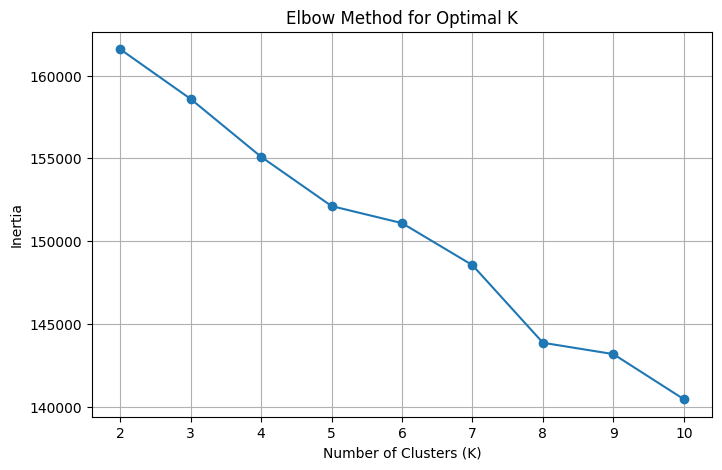

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [19]:
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

buyer_data["cluster"] = kmeans_final.fit_predict(scaled_data)

print("Cluster sizes:")
print(buyer_data["cluster"].value_counts().sort_index())

Cluster sizes:
0      95
1    1905
Name: cluster, dtype: int64


In [20]:
cluster_profile = buyer_data.groupby("cluster")[
    [
        "age_at_first_transaction",
        "satisfaction_score",
        "property_count",
        "total_purchase_value",
        "average_property_price"
    ]
].mean()

print(cluster_profile)

         age_at_first_transaction  satisfaction_score  property_count  \
cluster                                                                 
0                       52.031579            3.010526        3.663158   
1                       53.730184            3.029921        3.651969   

         total_purchase_value  average_property_price  
cluster                                                
0                1.284490e+06           351759.253783  
1                1.259173e+06           346857.103742  


In [21]:
for col in categorical_features:
    print(f"\n===== {col} =====")
    print(pd.crosstab(
        buyer_data["cluster"],
        buyer_data[col],
        normalize="index"
    ).round(3))


===== client_type =====
client_type  Company  Individual
cluster                         
0              0.053       0.947
1              0.051       0.949

===== gender =====
gender       F      M
cluster              
0        0.463  0.537
1        0.496  0.504

===== country =====
country  Australia  Belgium  Canada  Denmark  France  Germany  Mexico  Russia  \
cluster                                                                         
0             0.00    0.000   0.000    0.000   0.000    0.000   0.000   0.000   
1             0.02    0.023   0.045    0.008   0.028    0.029   0.021   0.019   

country   UK    USA  
cluster              
0        1.0  0.000  
1        0.0  0.807  

===== region =====
region   Alberta  Arizona  Baja California  Bavaria  Berlin  British Columbia  \
cluster                                                                         
0          0.000    0.000            0.000    0.000   0.000              0.00   
1          0.014    0.057            0

In [22]:
numeric_features = [
    "age_at_first_transaction",
    "satisfaction_score",
    "property_count",
    "total_purchase_value",
    "average_property_price"
]

categorical_encoded = [
    col for col in encoded_data.columns
    if col not in numeric_features
]

numeric_scaler = StandardScaler()

scaled_numeric = numeric_scaler.fit_transform(
    encoded_data[numeric_features]
)

scaled_numeric = pd.DataFrame(
    scaled_numeric,
    columns=numeric_features,
    index=encoded_data.index
)

scaled_categorical = encoded_data[categorical_encoded].astype(float)

mixed_scaled_data = pd.concat(
    [scaled_numeric, scaled_categorical],
    axis=1
)

print("Shape:", mixed_scaled_data.shape)
print("\nNumeric example:")
print(mixed_scaled_data[numeric_features].head())

print("\nCategorical example:")
print(mixed_scaled_data[categorical_encoded].head())

Shape: (2000, 83)

Numeric example:
   age_at_first_transaction  satisfaction_score  property_count  \
0                  0.077926            0.687089        0.413942   
1                  0.424134           -1.435740        1.605141   
2                  0.654939            0.687089        1.605141   
3                  0.597237            1.394698        2.796340   
4                 -0.325984            1.394698       11.134734   

   total_purchase_value  average_property_price  
0             -0.039140               -0.507841  
1              1.669967                0.303126  
2              1.153384               -0.212303  
3              1.000415               -1.134018  
4              6.881534               -0.947721  

Categorical example:
   client_type_Company  client_type_Individual  gender_F  gender_M  \
0                  0.0                     1.0       1.0       0.0   
1                  0.0                     1.0       0.0       1.0   
2                  0.0       

In [23]:
inertia_mixed = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(mixed_scaled_data)
    inertia_mixed.append(kmeans.inertia_)

for k, value in zip(range(2, 11), inertia_mixed):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 14437.65
K = 3: Inertia = 13140.82
K = 4: Inertia = 12204.38
K = 5: Inertia = 11500.13
K = 6: Inertia = 11024.19
K = 7: Inertia = 10636.77
K = 8: Inertia = 10288.21
K = 9: Inertia = 10037.71
K = 10: Inertia = 9846.21


In [24]:
silhouette_mixed = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(mixed_scaled_data)
    
    score = silhouette_score(mixed_scaled_data, labels)
    silhouette_mixed.append(score)

for k, score in zip(range(2, 11), silhouette_mixed):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.1239
K = 3: Silhouette Score = 0.1241
K = 4: Silhouette Score = 0.1031
K = 5: Silhouette Score = 0.0991
K = 6: Silhouette Score = 0.0940
K = 7: Silhouette Score = 0.0890
K = 8: Silhouette Score = 0.0889
K = 9: Silhouette Score = 0.0859
K = 10: Silhouette Score = 0.0855


In [26]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

buyer_data["cluster_3"] = kmeans_3.fit_predict(mixed_scaled_data)

print(buyer_data["cluster_3"].value_counts().sort_index())

0      51
1     899
2    1050
Name: cluster_3, dtype: int64


In [27]:
cluster_numeric_profile = buyer_data.groupby("cluster_3")[numeric_features].mean()

cluster_numeric_profile

,age_at_first_transaction,satisfaction_score,property_count,total_purchase_value,average_property_price
cluster_3,,,,,
0,62.431373,3.490196,7.294118,2.397660e+06,330963.050861
1,52.328142,3.165740,3.658509,1.465515e+06,404839.450428
2,54.354286,2.889524,3.470476,1.029498e+06,298428.695437


In [28]:
cluster_behavior = pd.crosstab(
    buyer_data["cluster_3"],
    [
        buyer_data["acquisition_purpose"],
        buyer_data["loan_applied"]
    ],
    normalize="index"
)

cluster_behavior.round(3)

acquisition_purpose   Home        Investment       
loan_applied            No    Yes         No    Yes
cluster_3                                          
0                    0.431  0.216      0.255  0.098
1                    0.473  0.247      0.169  0.111
2                    0.415  0.256      0.206  0.123

In [29]:
pd.crosstab(
    buyer_data["cluster_3"],
    buyer_data["client_type"],
    normalize="index"
).round(3)

client_type,Company,Individual
cluster_3,,
0,0.039,0.961
1,0.053,0.947
2,0.050,0.950


In [30]:
pd.crosstab(
    buyer_data["cluster_3"],
    buyer_data["country"],
    normalize="index"
).round(3)

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
cluster_3,,,,,,,,,,
0,0.000,0.020,0.020,0.000,0.020,0.020,0.000,0.000,0.059,0.863
1,0.016,0.023,0.038,0.011,0.024,0.023,0.017,0.017,0.043,0.788
2,0.024,0.020,0.048,0.005,0.029,0.032,0.024,0.020,0.050,0.749


In [31]:
pd.crosstab(
    buyer_data["cluster_3"],
    buyer_data["referral_channel"],
    normalize="index"
).round(3)

referral_channel,Agency,Client,Website
cluster_3,,,
0,0.255,0.039,0.706
1,0.350,0.095,0.555
2,0.359,0.100,0.541


In [32]:
pd.crosstab(
    buyer_data["cluster_3"],
    buyer_data["gender"],
    normalize="index"
).round(3)

gender,F,M
cluster_3,,
0,0.373,0.627
1,0.479,0.521
2,0.512,0.488


In [33]:
buyer_data["cluster"] = buyer_data["cluster_3"]

buyer_data["cluster"].value_counts().sort_index()

0      51
1     899
2    1050
Name: cluster, dtype: int64

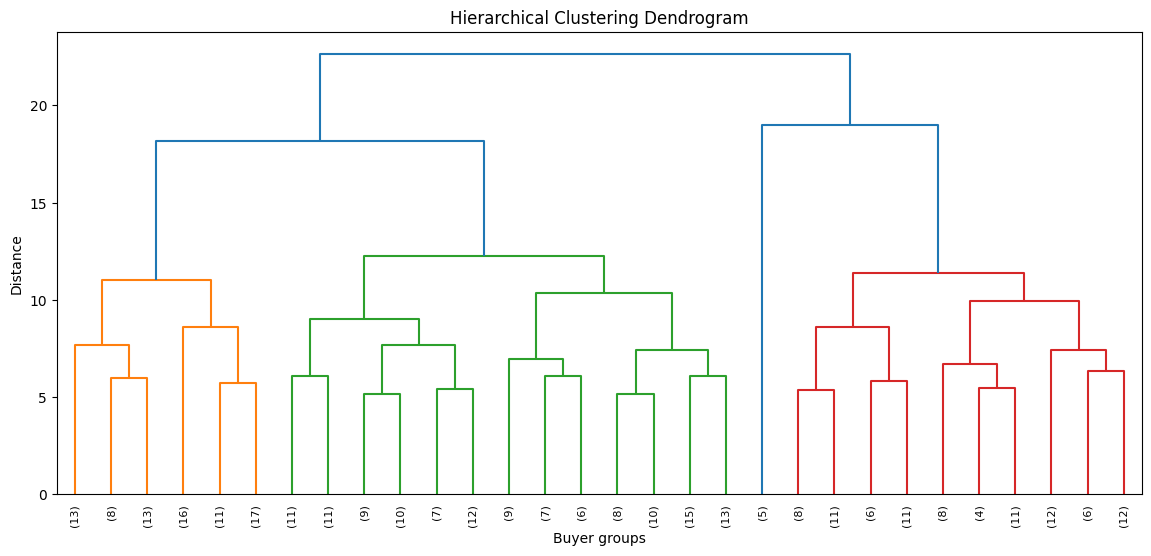

In [34]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

sample_data = mixed_scaled_data.sample(
    n=300,
    random_state=42
)

linkage_matrix = linkage(
    sample_data,
    method="ward"
)

plt.figure(figsize=(14, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Buyer groups")
plt.ylabel("Distance")
plt.show()


In [35]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

hierarchical_scores = []

for k in range(2, 7):
    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = hierarchical.fit_predict(mixed_scaled_data)
    score = silhouette_score(mixed_scaled_data, labels)
    
    hierarchical_scores.append(score)

for k, score in zip(range(2, 7), hierarchical_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.0819
K = 3: Silhouette Score = 0.0852
K = 4: Silhouette Score = 0.0624
K = 5: Silhouette Score = 0.0613
K = 6: Silhouette Score = 0.0575


In [36]:
hierarchical_final = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical_final.fit_predict(
    mixed_scaled_data
)

print(pd.Series(hierarchical_labels).value_counts().sort_index())

0    1063
1     900
2      37
dtype: int64


In [37]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(
    buyer_data["cluster"],
    hierarchical_labels
)

print(f"Adjusted Rand Index: {ari_score:.4f}")

Adjusted Rand Index: 0.3886


In [38]:
buyer_data.groupby("cluster")[[
    "property_count",
    "total_purchase_value",
    "average_property_price"
]].agg([
    "min",
    "median",
    "max"
]).round(2)

property_count            total_purchase_value              \
                   min median max                  min      median   
cluster                                                              
0                    6    7.0  13           1450519.57  2399689.67   
1                    3    4.0   5           1094026.34  1440682.21   
2                    3    3.0   5            463611.95  1034016.13   

                    average_property_price                        
                max                    min     median        max  
cluster                                                           
0        3653385.38              241753.26  324271.03  446987.99  
1        2163873.35              295346.08  397313.11  563423.50  
2        1463432.36              154537.32  300359.08  390183.64

In [39]:
cluster_names = {
    0: "High-Volume Multi-Property Buyers",
    1: "Higher-Value Property Buyers",
    2: "Lower-Value Property Buyers"
}

buyer_data["cluster_name"] = buyer_data["cluster"].map(cluster_names)

buyer_data["cluster_name"].value_counts()

Lower-Value Property Buyers          1050
Higher-Value Property Buyers          899
High-Volume Multi-Property Buyers      51
Name: cluster_name, dtype: int64

In [40]:
final_cluster_profile = (
    buyer_data
    .groupby(["cluster", "cluster_name"])
    .agg(
        buyer_count=("client_id", "count"),
        avg_age=("age_at_first_transaction", "mean"),
        avg_satisfaction=("satisfaction_score", "mean"),
        avg_property_count=("property_count", "mean"),
        avg_total_purchase_value=("total_purchase_value", "mean"),
        avg_property_price=("average_property_price", "mean")
    )
    .reset_index()
)

final_cluster_profile.round(2)

,cluster,cluster_name,buyer_count,avg_age,avg_satisfaction,avg_property_count,avg_total_purchase_value,avg_property_price
0,0,High-Volume Multi-Property Buyers,51,62.43,3.49,7.29,2397660.05,330963.05
1,1,Higher-Value Property Buyers,899,52.33,3.17,3.66,1465514.92,404839.45
2,2,Lower-Value Property Buyers,1050,54.35,2.89,3.47,1029497.51,298428.70


In [41]:
buyer_data.to_csv(
    "../data/buyer_segmented.csv",
    index=False
)

print("Saved successfully.")
print("Shape:", buyer_data.shape)

Saved successfully.
Shape: (2000, 19)


In [42]:
buyer_data.isna().sum()

client_id                   0
client_type                 0
first_name                  0
last_name                   0
date_of_birth               0
gender                      0
country                     0
region                      0
acquisition_purpose         0
satisfaction_score          0
loan_applied                0
referral_channel            0
property_count              0
total_purchase_value        0
average_property_price      0
age_at_first_transaction    0
cluster                     0
cluster_3                   0
cluster_name                0
dtype: int64

In [43]:
dashboard_data = buyer_data.drop(
    columns=["first_name", "last_name", "cluster_3"]
).copy()

dashboard_data.to_csv(
    "../data/buyer_segmented_dashboard.csv",
    index=False
)

print("Dashboard dataset saved successfully.")
print("Shape:", dashboard_data.shape)
print(dashboard_data.columns.tolist())

Dashboard dataset saved successfully.
Shape: (2000, 16)
['client_id', 'client_type', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'property_count', 'total_purchase_value', 'average_property_price', 'age_at_first_transaction', 'cluster', 'cluster_name']
